In [25]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [26]:
df = pd.read_excel("D:/Hackathon/Kenexai-2k26/Dataset/final_student_data_v3.xlsx")

print(df.shape)
df.head()

(2000, 18)


,id,sgpa1,sgpa2,sgpa3,sgpa4,cgpa,active backlogs,total backlogs,10th mark,12th mark,studytime,part timejob,math,dsa,networks,os,attendance,career preference
0,1,6.79,7.94,7.12,6.22,7.02,0,0,81.91,84.23,13,no,52,88,90,85,85.93,higher study
1,2,9.82,5.18,7.00,6.27,7.07,0,0,45.37,33.45,10,yes,37,34,81,81,71.06,job
2,3,6.74,6.52,6.53,7.96,6.94,0,0,56.23,64.97,0,yes,50,48,50,86,70.80,higher study
3,4,8.72,8.62,4.71,7.46,7.38,0,0,77.44,86.19,2,yes,97,58,77,88,97.16,job
4,5,6.75,7.84,7.82,8.37,7.70,4,5,65.31,75.22,2,yes,55,53,37,71,72.13,none


In [27]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

In [28]:
df.dtypes

id                     int64
sgpa1                float64
sgpa2                float64
sgpa3                float64
sgpa4                float64
cgpa                 float64
active backlogs        int64
total backlogs         int64
10th mark            float64
12th mark            float64
studytime              int64
part timejob          object
math                   int64
dsa                    int64
networks               int64
os                     int64
attendance           float64
career preference     object
dtype: object

In [29]:
df["stress_score"] = (
    (10 - df["cgpa"]) * 2 +
    df["active backlogs"] * 3 +
    df["total backlogs"] +
    (5 - df["studytime"])
)

In [30]:
def stress_category(score):
    if score < 5:
        return "low"
    elif score < 10:
        return "medium"
    else:
        return "high"

df["stress level"] = df["stress_score"].apply(stress_category)

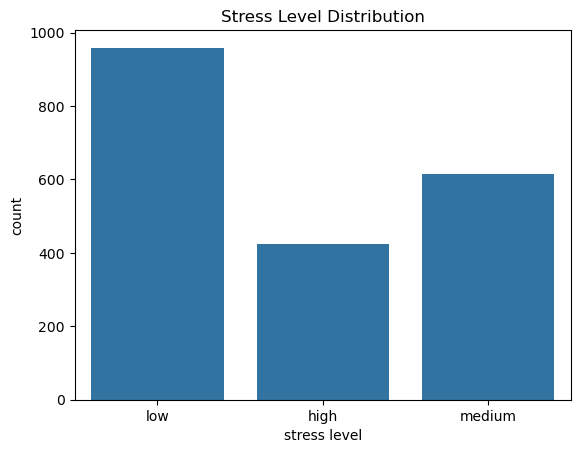

In [31]:
sns.countplot(x="stress level", data=df)
plt.title("Stress Level Distribution")
plt.show()

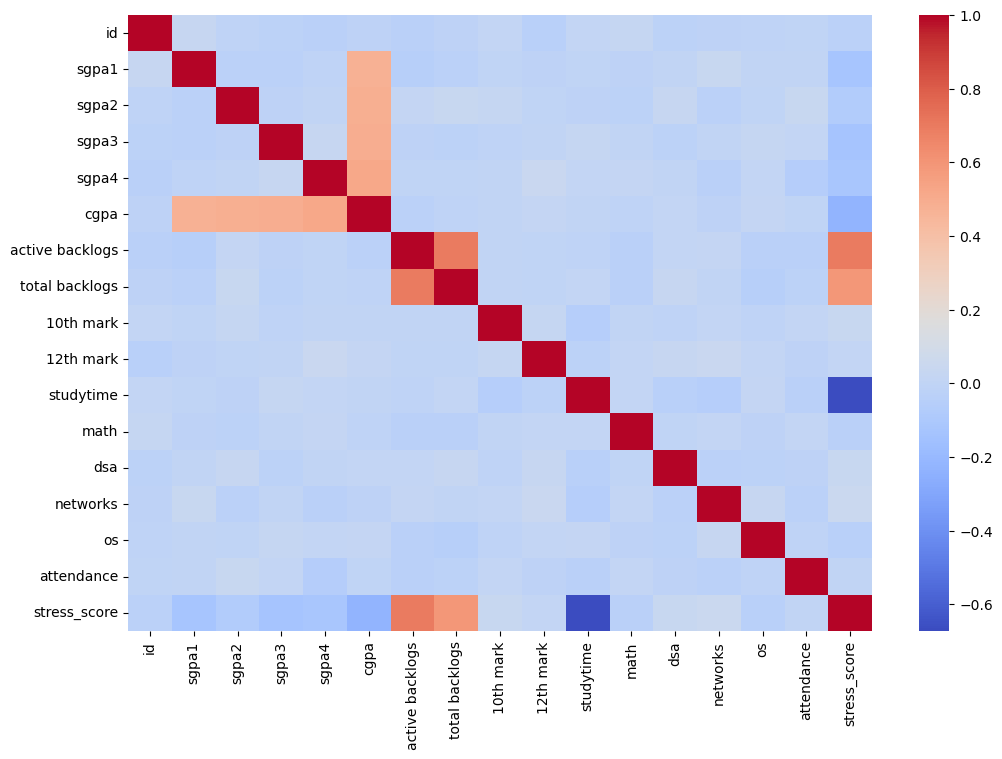

In [32]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

In [34]:
le = LabelEncoder()

df["stress level"] = le.fit_transform(df["stress level"])

In [15]:
X = df.drop(["risk","stress_cluster"], axis=1)

y = df["risk"]

In [35]:
df = pd.get_dummies(df, drop_first=True)

In [36]:
X = df.drop(["stress level"], axis=1)

y = df["stress level"]

In [37]:
training_columns = X.columns

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))

model.add(Dense(3, activation="softmax"))

c:\Users\daxgo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
)

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5258 - loss: 0.9767 - val_accuracy: 0.6938 - val_loss: 0.7505 - learning_rate: 0.0010
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6594 - loss: 0.7539 - val_accuracy: 0.8344 - val_loss: 0.5178 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 0.5622 - val_accuracy: 0.8656 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8211 - loss: 0.4465 - val_accuracy: 0.9000 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8398 - loss: 0.3786 - val_accuracy: 0.9281 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8594 - loss: 0.3302 - val_accuracy: 0.9312 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8625 - loss: 0.3089 - val_ac

In [44]:
pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

print("Accuracy:", accuracy_score(y_test, pred_class))

print(classification_report(y_test, pred_class))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.9525
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        86
           1       0.99      0.96      0.98       189
           2       0.91      0.94      0.93       125

    accuracy                           0.95       400
   macro avg       0.94      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



In [45]:
all_scaled = scaler.transform(X)

pred = model.predict(all_scaled)

stress_class = np.argmax(pred, axis=1)

df["predicted_stress"] = le.inverse_transform(stress_class)

print(df[["predicted_stress"]])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
     predicted_stress
0                 low
1                 low
2                high
3              medium
4                high
...               ...
1995              low
1996              low
1997           medium
1998           medium
1999           medium

[2000 rows x 1 columns]


In [46]:
model.save("student_stress_level_model.h5")

In [47]:
from tensorflow.keras.models import load_model

model = load_model("student_stress_level_model.h5")

In [48]:
new_student = pd.DataFrame({
    "cgpa":[6.0],
    "active backlogs":[1],
    "total backlogs":[2],
    "studytime":[2],
    "attendance":[65]
})

In [49]:
new_student = pd.get_dummies(new_student)

new_student = new_student.reindex(columns=training_columns, fill_value=0)

In [50]:
new_scaled = scaler.transform(new_student)

In [51]:
pred = model.predict(new_scaled)

stress_class = np.argmax(pred, axis=1)

stress_level = le.inverse_transform(stress_class)

print("Predicted Stress Level:", stress_level[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
Predicted Stress Level: medium
